# Image compression

In [1]:
# Modules
import matplotlib.pyplot as plt
from matplotlib.image import imread
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
%matplotlib inline
from warnings import filterwarnings
filterwarnings('ignore')

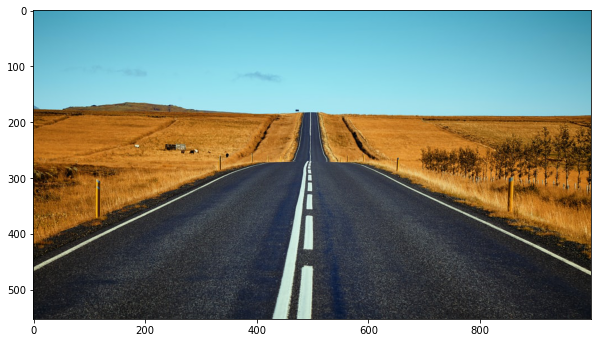

In [2]:
# Read the image
plt.figure(figsize=(10,10))
img = imread('./data/roadimage.jpeg')
plt.rcParams["axes.grid"] = False
plt.imshow(img)

In [ ]:
img_size = img.shape
print("Shape of the image is ",img_size)

In [ ]:
# Reshape it to be 2-dimension
X = img.reshape(img_size[0] * img_size[1], img_size[2])

In [ ]:
# Run the Kmeans algorithm
km = KMeans(n_clusters=4)
km.fit(X)

In [ ]:
# Labels corresponding to clusters for each pixel
km.labels_.shape

In [ ]:
# Use the centroids to compress the image
X_compressed = km.cluster_centers_[km.labels_]
X_compressed = np.clip(X_compressed.astype('uint8'), 0, 255)

In [ ]:
# Reshape X_recovered to have the same dimension as the original image 
X_compressed = X_compressed.reshape(img_size[0], img_size[1], img_size[2])

In [ ]:
# Plot the original and the compressed image next to each other
fig, ax = plt.subplots(1, 2, figsize = (12, 8))
ax[0].imshow(img)
ax[0].set_title('Original Image')
ax[1].imshow(X_compressed)
ax[1].set_title('Compressed Image with 4 colors')
for ax in fig.axes:
    ax.axis('off')
plt.tight_layout();

### Task 1: Find out the optimal number of clusters to be used
### Task 2: Find out an optimal compression ratio